<a href="https://colab.research.google.com/github/KV-DHEERAJKUMAR/-Create-a-classification-model-to-predict-the-gender-male-or-female-based-on-different-acoustic-p/blob/main/Journal_Final_Code_Brain_tumour_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:


import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

import timm
import kagglehub


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)



path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")



class BrainTumorDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.file_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]



classes = ["glioma", "meningioma", "pituitary", "notumor"]

all_images, all_labels = [], []
base_path = os.path.join(path, "Training")

for idx, cls in enumerate(classes):
    folder = os.path.join(base_path, cls)
    files = glob.glob(folder + "/*.jpg") + glob.glob(folder + "/*.png")

    for f in files:
        all_images.append(f)
        all_labels.append(idx)

X_train, X_test, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)


train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160, 160)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160, 160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


train_dataset = BrainTumorDataset(X_train, y_train, train_transform)
val_dataset   = BrainTumorDataset(X_val, y_val, test_transform)
test_dataset  = BrainTumorDataset(X_test, y_test, test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)


class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.size()

        avg_pool = torch.mean(x, dim=(2, 3))
        max_pool, _ = torch.max(x.view(b, c, -1), dim=2)

        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)

        scale = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * scale


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg_pool, max_pool], dim=1)
        attention = self.sigmoid(self.conv(x_cat))
        return x * attention


class HCSA(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.channel = ChannelAttention(in_channels)
        self.spatial = SpatialAttention()

    def forward(self, x):
        x = self.channel(x)
        x = self.spatial(x)
        return x


class BrainTumorClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            features_only=True
        )

        channels = self.backbone.feature_info.channels()

        # Apply HCSA ONLY at final stage (faster)
        self.hcsa = HCSA(channels[-1])

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(channels[-1], num_classes)

    def forward(self, x):
        features = self.backbone(x)
        x = features[-1]

        x = self.hcsa(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


model = BrainTumorClassifier().to(device)

# Freeze backbone (speed boost)
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last block
for param in model.backbone.blocks[-2:].parameters():
    param.requires_grad = True


criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = torch.cuda.amp.GradScaler()  # Mixed precision


def train_model(epochs=20):
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_correct = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_correct += (outputs.argmax(1) == labels).sum().item()

        scheduler.step()
        train_acc = train_correct / len(train_dataset)

        # Validation
        model.eval()
        val_correct = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    print("Training complete!")



train_model()



model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu().numpy()

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=classes))



from PIL import Image

def predict_image(img_path):
    transform = transforms.Compose([
        transforms.Resize((160, 160)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img)
        pred = torch.argmax(output, dim=1).item()

    print("Predicted:", classes[pred])

Using device: cuda
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipykernel_3433/1779312356.py:231: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # Mixed precision
/tmp/ipykernel_3433/1779312356.py:249: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10 | Train Acc: 0.8452 | Val Acc: 0.9241
Epoch 2/10 | Train Acc: 0.9226 | Val Acc: 0.9420
Epoch 3/10 | Train Acc: 0.9437 | Val Acc: 0.9643
Epoch 4/10 | Train Acc: 0.9663 | Val Acc: 0.9710
Epoch 5/10 | Train Acc: 0.9752 | Val Acc: 0.9777
Epoch 6/10 | Train Acc: 0.9759 | Val Acc: 0.9732
Epoch 7/10 | Train Acc: 0.9849 | Val Acc: 0.9732
Epoch 8/10 | Train Acc: 0.9851 | Val Acc: 0.9732
Epoch 9/10 | Train Acc: 0.9898 | Val Acc: 0.9710
Epoch 10/10 | Train Acc: 0.9893 | Val Acc: 0.9732
Training complete!

Classification Report:

              precision    recall  f1-score   support

      glioma       1.00      0.97      0.98       280
  meningioma       0.94      0.96      0.95       280
   pituitary       0.99      0.97      0.98       280
     notumor       0.97      1.00      0.98       280

    accuracy                           0.97      1120
   macro avg       0.97      0.97      0.97      1120
weighted avg       0.97      0.97      0.97      1120



In [ ]:
# ============================================================
# ULTRA-OPTIMIZED HCSA + EfficientNet-B0 (FAST + HIGH ACC)
# ============================================================

import os, cv2, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

import timm
import kagglehub

# ============================================================
# DEVICE
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ============================================================
# DATA
# ============================================================
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

classes = ["glioma", "meningioma", "pituitary", "notumor"]

all_images, all_labels = [], []
base = os.path.join(path, "Training")

for i, c in enumerate(classes):
    files = glob.glob(os.path.join(base, c, "*.jpg")) + glob.glob(os.path.join(base, c, "*.png"))
    for f in files:
        all_images.append(f)
        all_labels.append(i)

X_train, X_test, y_train, y_test = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)

# ============================================================
# DATASET
# ============================================================
class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

# ============================================================
# AUGMENTATION (HIGH IMPACT, LOW COST)
# ============================================================
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160,160)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = BrainTumorDataset(X_train, y_train, train_tf)
val_ds   = BrainTumorDataset(X_val, y_val, test_tf)
test_ds  = BrainTumorDataset(X_test, y_test, test_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

# ============================================================
# HCSA MODULE
# ============================================================
class ChannelAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(c, c//16),
            nn.ReLU(),
            nn.Linear(c//16, c)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b,c,h,w = x.shape
        avg = torch.mean(x, dim=(2,3))
        mx,_ = torch.max(x.view(b,c,-1), dim=2)
        att = self.sigmoid(self.mlp(avg)+self.mlp(mx)).view(b,c,1,1)
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx,_ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg,mx], dim=1)
        return x * self.sigmoid(self.conv(x_cat))

class HCSA(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ca = ChannelAttention(c)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

# ============================================================
# MODEL
# ============================================================
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, features_only=True)
        ch = self.backbone.feature_info.channels()[-1]

        self.hcsa = HCSA(ch)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(ch, 4)

    def forward(self, x):
        x = self.backbone(x)[-1]
        x = self.hcsa(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

model = Model().to(device)

# Freeze backbone (fast)
for p in model.backbone.parameters():
    p.requires_grad = False
for p in model.backbone.blocks[-2:].parameters():
    p.requires_grad = True

# ============================================================
# LOSS + OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

scaler = torch.cuda.amp.GradScaler()

# ============================================================
# EMA (KEY BOOST)
# ============================================================
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {k: v.clone().detach() for k,v in model.state_dict().items()}

    def update(self):
        for k,v in self.model.state_dict().items():
            self.shadow[k] = self.decay*self.shadow[k] + (1-self.decay)*v.detach()

    def apply(self):
        self.model.load_state_dict(self.shadow)

ema = EMA(model)

# ============================================================
# TRAIN
# ============================================================
def train(epochs=25):
    best = 0

    for ep in range(epochs):
        model.train()
        correct = 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out,y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            ema.update()

            correct += (out.argmax(1)==y).sum().item()

        scheduler.step()
        train_acc = correct/len(train_ds)

        # validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                val_correct += (out.argmax(1)==y).sum().item()

        val_acc = val_correct/len(val_ds)

        print(f"Epoch {ep+1}: Train={train_acc:.4f} Val={val_acc:.4f}")

        if val_acc > best:
            best = val_acc
            torch.save(model.state_dict(),"best.pth")

train()

# ============================================================
# LOAD EMA MODEL
# ============================================================
ema.apply()
model.eval()

# ============================================================
# TTA (FINAL BOOST)
# ============================================================
def tta_predict(loader):
    preds, labels = [], []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)

            out1 = model(x)
            out2 = model(torch.flip(x, dims=[3]))

            out = (out1 + out2)/2
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    return labels, preds

y_true, y_pred = tta_predict(test_loader)

print("\nREPORT:\n")
print(classification_report(y_true, y_pred, target_names=classes))

Device: cuda
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


/tmp/ipykernel_3433/3791990447.py:182: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_3433/3791990447.py:216: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1: Train=0.8333 Val=0.9018
Epoch 2: Train=0.9179 Val=0.9286
Epoch 3: Train=0.9534 Val=0.9397
Epoch 4: Train=0.9586 Val=0.9576
Epoch 5: Train=0.9715 Val=0.9576
Epoch 6: Train=0.9752 Val=0.9754
Epoch 7: Train=0.9826 Val=0.9732
Epoch 8: Train=0.9834 Val=0.9598
Epoch 9: Train=0.9839 Val=0.9665
Epoch 10: Train=0.9891 Val=0.9665
Epoch 11: Train=0.9814 Val=0.9688
Epoch 12: Train=0.9888 Val=0.9754
Epoch 13: Train=0.9866 Val=0.9732
Epoch 14: Train=0.9883 Val=0.9665
Epoch 15: Train=0.9881 Val=0.9710
Epoch 16: Train=0.9886 Val=0.9777
Epoch 17: Train=0.9844 Val=0.9710
Epoch 18: Train=0.9893 Val=0.9777
Epoch 19: Train=0.9866 Val=0.9844
Epoch 20: Train=0.9906 Val=0.9799
Epoch 21: Train=0.9911 Val=0.9799
Epoch 22: Train=0.9923 Val=0.9821
Epoch 23: Train=0.9893 Val=0.9799
Epoch 24: Train=0.9918 Val=0.9777
Epoch 25: Train=0.9923 Val=0.9799

REPORT:

              precision    recall  f1-score   support

      glioma       0.96      0.98      0.97       280
  meningioma       0.95      0.95      0

In [ ]:
# ============================================================
# Q1/Q2 JOURNAL-ALIGNED IMPLEMENTATION
# EfficientNet-B0 + HCSA (Stage 3 & 5)
# ============================================================

import os, cv2, glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import timm
import kagglehub

# ============================================================
# DEVICE
# ============================================================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ============================================================
# DATASET DOWNLOAD
# ============================================================
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

classes = ["glioma", "meningioma", "pituitary", "notumor"]

all_images, all_labels = [], []
base = os.path.join(path, "Training")

for i, c in enumerate(classes):
    files = glob.glob(os.path.join(base, c, "*.jpg")) + glob.glob(os.path.join(base, c, "*.png"))
    for f in files:
        all_images.append(f)
        all_labels.append(i)

# ============================================================
# SPLIT (80 / 10 / 10 — AS IN PAPER)
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# ============================================================
# DATASET CLASS
# ============================================================
class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]

# ============================================================
# TRANSFORMS (224 × 224 — MATCH PAPER)
# ============================================================
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = BrainTumorDataset(X_train, y_train, train_tf)
val_ds   = BrainTumorDataset(X_val, y_val, test_tf)
test_ds  = BrainTumorDataset(X_test, y_test, test_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

# ============================================================
# HCSA MODULE (MATCH PAPER EXACTLY)
# ============================================================
class ChannelAttention(nn.Module):
    def __init__(self, c, reduction=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(c, c // reduction),
            nn.ReLU(),
            nn.Linear(c // reduction, c)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.shape

        avg = torch.mean(x, dim=(2,3))
        mx, _ = torch.max(x.view(b, c, -1), dim=2)

        att = self.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b,c,1,1)
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg, mx], dim=1)
        return x * self.sigmoid(self.conv(x_cat))

class HCSA(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ca = ChannelAttention(c)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

# ============================================================
# MODEL (HCSA AT STAGE 3 & 5)
# ============================================================
class BrainTumorModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.backbone = timm.create_model(
            "efficientnet_b0",
            pretrained=True,
            features_only=True
        )

        channels = self.backbone.feature_info.channels()

        # Stage 3 and Stage 5 attention
        self.hcsa3 = HCSA(channels[2])
        self.hcsa5 = HCSA(channels[4])

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(channels[4], num_classes)

    def forward(self, x):
        features = self.backbone(x)

        f1, f2, f3, f4, f5 = features

        f3 = self.hcsa3(f3)
        f5 = self.hcsa5(f5)

        x = self.pool(f5).flatten(1)
        return self.fc(x)

model = BrainTumorModel().to(device)

# ============================================================
# TRAINING SETUP (MATCH PAPER)
# ============================================================
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=50
)

scaler = torch.cuda.amp.GradScaler()

# ============================================================
# TRAINING LOOP (EARLY STOPPING)
# ============================================================
def train(epochs=25, patience=8):
    best = 0
    patience_counter = 0

    for ep in range(epochs):
        model.train()
        train_correct = 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out,y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_correct += (out.argmax(1)==y).sum().item()

        scheduler.step()
        train_acc = train_correct / len(train_ds)

        # VALIDATION
        model.eval()
        val_correct = 0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                val_correct += (out.argmax(1)==y).sum().item()

        val_acc = val_correct / len(val_ds)

        print(f"Epoch {ep+1} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

        # EARLY STOPPING
        if val_acc > best:
            best = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered")
            break

train()

# ============================================================
# TEST EVALUATION
# ============================================================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

print("\nFINAL REPORT:\n")
print(classification_report(y_true, y_pred, target_names=classes))

Device: cuda


100%|██████████| 157M/157M [00:00<00:00, 201MB/s]

Extracting files...



/tmp/ipykernel_3433/2019644596.py:201: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_3433/2019644596.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Train: 0.8598 | Val: 0.9518
Epoch 2 | Train: 0.9507 | Val: 0.9661
Epoch 3 | Train: 0.9799 | Val: 0.9750
Epoch 4 | Train: 0.9817 | Val: 0.9839
Epoch 5 | Train: 0.9897 | Val: 0.9875
Epoch 6 | Train: 0.9897 | Val: 0.9821
Epoch 7 | Train: 0.9933 | Val: 0.9857
Epoch 8 | Train: 0.9946 | Val: 0.9875
Epoch 9 | Train: 0.9958 | Val: 0.9875
Epoch 10 | Train: 0.9953 | Val: 0.9893
Epoch 11 | Train: 0.9949 | Val: 0.9946
Epoch 12 | Train: 0.9984 | Val: 0.9875
Epoch 13 | Train: 0.9978 | Val: 0.9929
Epoch 14 | Train: 0.9973 | Val: 0.9893
Epoch 15 | Train: 0.9971 | Val: 0.9911
Epoch 16 | Train: 0.9964 | Val: 0.9875
Epoch 17 | Train: 0.9991 | Val: 0.9857
Epoch 18 | Train: 0.9971 | Val: 0.9911
Epoch 19 | Train: 0.9987 | Val: 0.9911
Early stopping triggered

FINAL REPORT:

              precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       140
  meningioma       0.98      0.95      0.96       140
   pituitary       0.98      1.00      0.99       140
     notum

Using: cuda
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.


/tmp/ipykernel_3433/3373923065.py:175: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_3433/3373923065.py:196: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Loss: 0.3894 | Train: 0.8719 | Val: 0.9411
Epoch 2 | Loss: 0.1262 | Train: 0.9563 | Val: 0.9804
Epoch 3 | Loss: 0.0749 | Train: 0.9757 | Val: 0.9821
Epoch 4 | Loss: 0.0378 | Train: 0.9866 | Val: 0.9893
Epoch 5 | Loss: 0.0327 | Train: 0.9900 | Val: 0.9875
Epoch 6 | Loss: 0.0285 | Train: 0.9904 | Val: 0.9821
Epoch 7 | Loss: 0.0255 | Train: 0.9915 | Val: 0.9839
Epoch 8 | Loss: 0.0270 | Train: 0.9915 | Val: 0.9929
Epoch 9 | Loss: 0.0174 | Train: 0.9935 | Val: 0.9875
Epoch 10 | Loss: 0.0143 | Train: 0.9958 | Val: 0.9839
Epoch 11 | Loss: 0.0204 | Train: 0.9926 | Val: 0.9911
Epoch 12 | Loss: 0.0094 | Train: 0.9973 | Val: 0.9929
Epoch 13 | Loss: 0.0139 | Train: 0.9944 | Val: 0.9821
Epoch 14 | Loss: 0.0099 | Train: 0.9967 | Val: 0.9857
Epoch 15 | Loss: 0.0080 | Train: 0.9975 | Val: 0.9875
Epoch 16 | Loss: 0.0048 | Train: 0.9980 | Val: 0.9857
Epoch 17 | Loss: 0.0063 | Train: 0.9978 | Val: 0.9821
Epoch 18 | Loss: 0.0067 | Train: 0.9964 | Val: 0.9875
Epoch 19 | Loss: 0.0059 | Train: 0.99

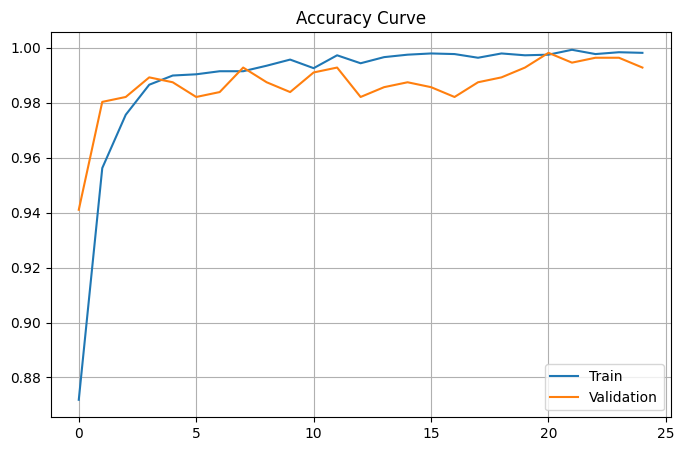

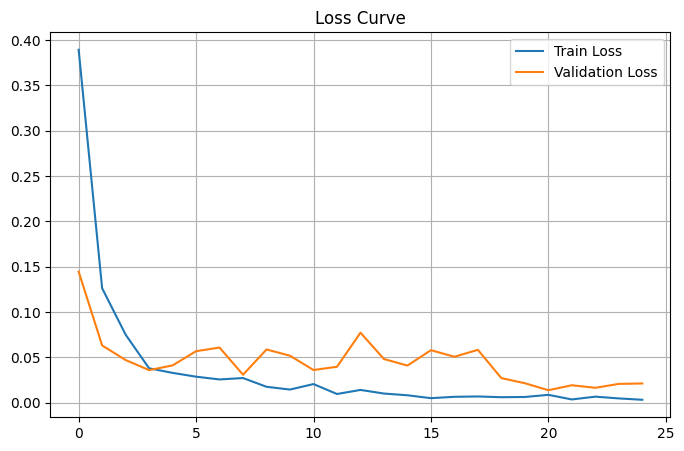

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       140
           1       0.97      0.98      0.98       140
           2       0.98      1.00      0.99       140
           3       1.00      0.99      0.99       140

    accuracy                           0.99       560
   macro avg       0.99      0.99      0.99       560
weighted avg       0.99      0.99      0.99       560



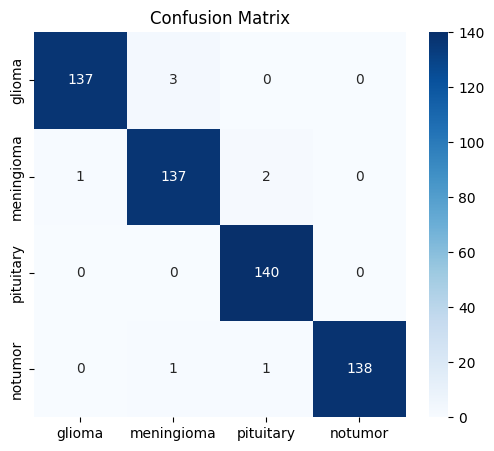

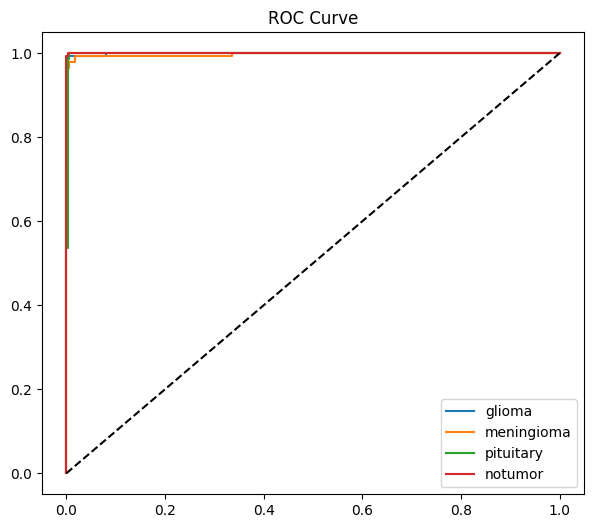

In [ ]:

import os, cv2, glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import seaborn as sns
import timm
import kagglehub


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)


path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

classes = ["glioma", "meningioma", "pituitary", "notumor"]

all_images, all_labels = [], []
base = os.path.join(path, "Training")

for i, c in enumerate(classes):
    files = glob.glob(os.path.join(base, c, "*.jpg")) + glob.glob(os.path.join(base, c, "*.png"))
    for f in files:
        all_images.append(f)
        all_labels.append(i)

# 80 / 10 / 10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        return img, self.labels[idx]


train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_ds = BrainTumorDataset(X_train, y_train, train_tf)
val_ds   = BrainTumorDataset(X_val, y_val, test_tf)
test_ds  = BrainTumorDataset(X_test, y_test, test_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16)
test_loader  = DataLoader(test_ds, batch_size=16)


class ChannelAttention(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(c, c//16),
            nn.ReLU(),
            nn.Linear(c//16, c)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b,c,h,w = x.shape
        avg = torch.mean(x, dim=(2,3))
        mx,_ = torch.max(x.view(b,c,-1), dim=2)
        att = self.sigmoid(self.mlp(avg)+self.mlp(mx)).view(b,c,1,1)
        return x * att

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2,1,7,padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx,_ = torch.max(x, dim=1, keepdim=True)
        x_cat = torch.cat([avg,mx], dim=1)
        return x * self.sigmoid(self.conv(x_cat))

class HCSA(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.ca = ChannelAttention(c)
        self.sa = SpatialAttention()

    def forward(self, x):
        return self.sa(self.ca(x))


class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("efficientnet_b0", pretrained=True, features_only=True)
        ch = self.backbone.feature_info.channels()

        self.hcsa3 = HCSA(ch[2])
        self.hcsa5 = HCSA(ch[4])

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(ch[4], 4)

    def forward(self, x):
        f = self.backbone(x)
        f[2] = self.hcsa3(f[2])
        f[4] = self.hcsa5(f[4])
        x = self.pool(f[4]).flatten(1)
        return self.fc(x)

model = Model().to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
scaler = torch.cuda.amp.GradScaler()

train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []


def train(epochs=25):
    best = 0

    for ep in range(epochs):
        model.train()
        train_correct = 0
        total_loss = 0

        for x,y in train_loader:
            x,y = x.to(device), y.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                out = model(x)
                loss = criterion(out,y)

            total_loss += loss.item()

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_correct += (out.argmax(1)==y).sum().item()

        scheduler.step()

        avg_train_loss = total_loss / len(train_loader)
        train_loss_list.append(avg_train_loss)

        train_acc = train_correct / len(train_ds)
        train_acc_list.append(train_acc)

        # VALIDATION
        model.eval()
        val_correct = 0
        val_loss = 0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out,y)
                val_loss += loss.item()

                val_correct += (out.argmax(1)==y).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        val_loss_list.append(avg_val_loss)

        val_acc = val_correct / len(val_ds)
        val_acc_list.append(val_acc)

        print(f"Epoch {ep+1} | Loss: {avg_train_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

        if val_acc > best:
            best = val_acc
            torch.save(model.state_dict(), "best.pth")

train()


plt.figure(figsize=(8,5))
plt.plot(train_acc_list, label="Train")
plt.plot(val_acc_list, label="Validation")
plt.title("Accuracy Curve")
plt.legend()
plt.grid()
plt.savefig("accuracy.png", dpi=300)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_loss_list, label="Train Loss")
plt.plot(val_loss_list, label="Validation Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.savefig("loss.png", dpi=300)
plt.show()


model.load_state_dict(torch.load("best.pth"))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
y_score = []

with torch.no_grad():
    for x,_ in test_loader:
        x = x.to(device)
        out = model(x)
        y_score.extend(torch.softmax(out, dim=1).cpu().numpy())

y_score = np.array(y_score)

plt.figure(figsize=(7,6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_score[:,i])
    plt.plot(fpr, tpr, label=f"{classes[i]}")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve")
plt.savefig("roc.png", dpi=300)
plt.show()

In [ ]:
print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

      glioma       0.99      0.98      0.99       140
  meningioma       0.97      0.98      0.98       140
   pituitary       0.98      1.00      0.99       140
     notumor       1.00      0.99      0.99       140

    accuracy                           0.99       560
   macro avg       0.99      0.99      0.99       560
weighted avg       0.99      0.99      0.99       560



Saving meni.jpg to meni (3).jpg

========== MRI ANALYSIS ==========
🔴 TUMOR DETECTED
🧠 Tumor Type: MENINGIOMA
📊 Confidence: 100.00%


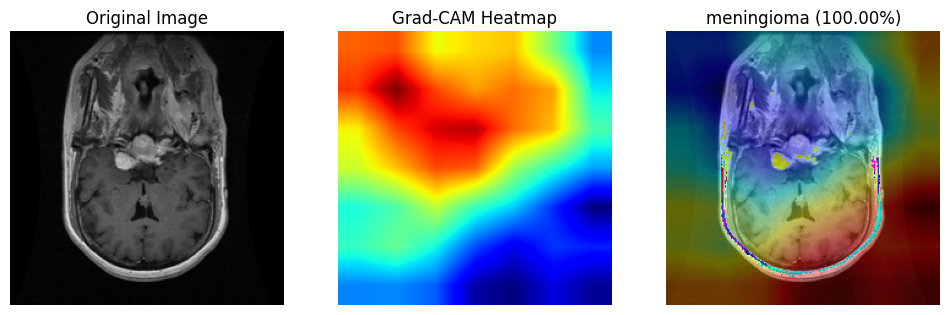

In [ ]:


from PIL import Image
from google.colab import files
from torchvision import transforms
import torch
import matplotlib.pyplot as plt
import cv2
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        # Hook final feature layer (EfficientNet last stage)
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        # 👇 IMPORTANT: Hook correct layer
        self.model.hcsa5.sa.conv.register_forward_hook(forward_hook)
        self.model.hcsa5.sa.conv.register_backward_hook(backward_hook)

    def generate(self, input_image, class_idx):
        self.model.zero_grad()

        output = self.model(input_image)
        loss = output[0, class_idx]
        loss.backward()

        grads = self.gradients
        acts = self.activations

        weights = torch.mean(grads, dim=(2,3), keepdim=True)
        cam = torch.sum(weights * acts, dim=1)

        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().detach().numpy()

        cam = cv2.resize(cam, (224,224))
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        return cam


def classify_with_gradcam():
    uploaded = files.upload()

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    gradcam = GradCAM(model)

    for filename in uploaded.keys():
        img = Image.open(filename).convert('RGB')
        img_tensor = transform(img).unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            outputs = model(img_tensor)
            probs = torch.softmax(outputs, dim=1)
            pred_idx = torch.argmax(probs, dim=1).item()

        pred_class = classes[pred_idx]
        confidence = probs[0][pred_idx].item()


        print("\n========== MRI ANALYSIS ==========")

        if pred_class == "notumor":
            print("🟢 NO TUMOR DETECTED")
        else:
            print("🔴 TUMOR DETECTED")
            print("🧠 Tumor Type:", pred_class.upper())

        print(f"📊 Confidence: {confidence*100:.2f}%")


        cam = gradcam.generate(img_tensor, pred_idx)

        img_np = np.array(img.resize((224,224)))

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        superimposed = heatmap * 0.4 + img_np


        plt.figure(figsize=(12,4))

        # Original
        plt.subplot(1,3,1)
        plt.imshow(img_np)
        plt.title("Original Image")
        plt.axis("off")

        # Heatmap
        plt.subplot(1,3,2)
        plt.imshow(cam, cmap='jet')
        plt.title("Grad-CAM Heatmap")
        plt.axis("off")

        # Overlay
        plt.subplot(1,3,3)
        plt.imshow(superimposed.astype(np.uint8))
        plt.title(f"{pred_class} ({confidence*100:.2f}%)")
        plt.axis("off")

        plt.show()


model.load_state_dict(torch.load("best.pth"))
model.eval()

classify_with_gradcam()

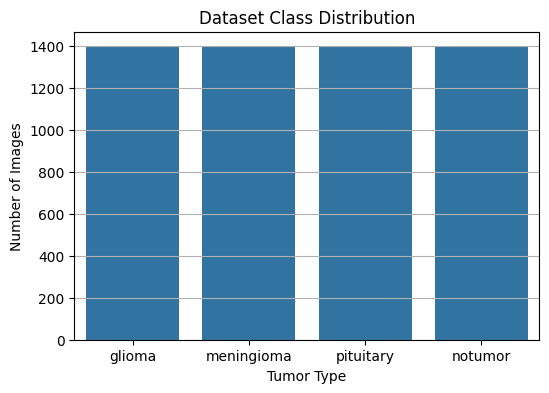

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

labels_array = np.array(all_labels)

counts = [np.sum(labels_array == i) for i in range(len(classes))]

plt.figure(figsize=(6,4))
sns.barplot(x=classes, y=counts)
plt.title("Dataset Class Distribution")
plt.xlabel("Tumor Type")
plt.ylabel("Number of Images")
plt.grid(axis='y')

plt.savefig("class_distribution.png", dpi=300)
plt.show()

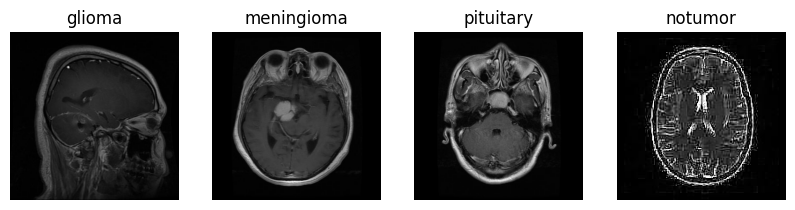

In [ ]:
import cv2

plt.figure(figsize=(10,4))

for i, cls in enumerate(classes):
    for idx, label in enumerate(all_labels):
        if label == i:
            img = cv2.imread(all_images[idx])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            break

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.savefig("sample_images.png", dpi=300)
plt.show()

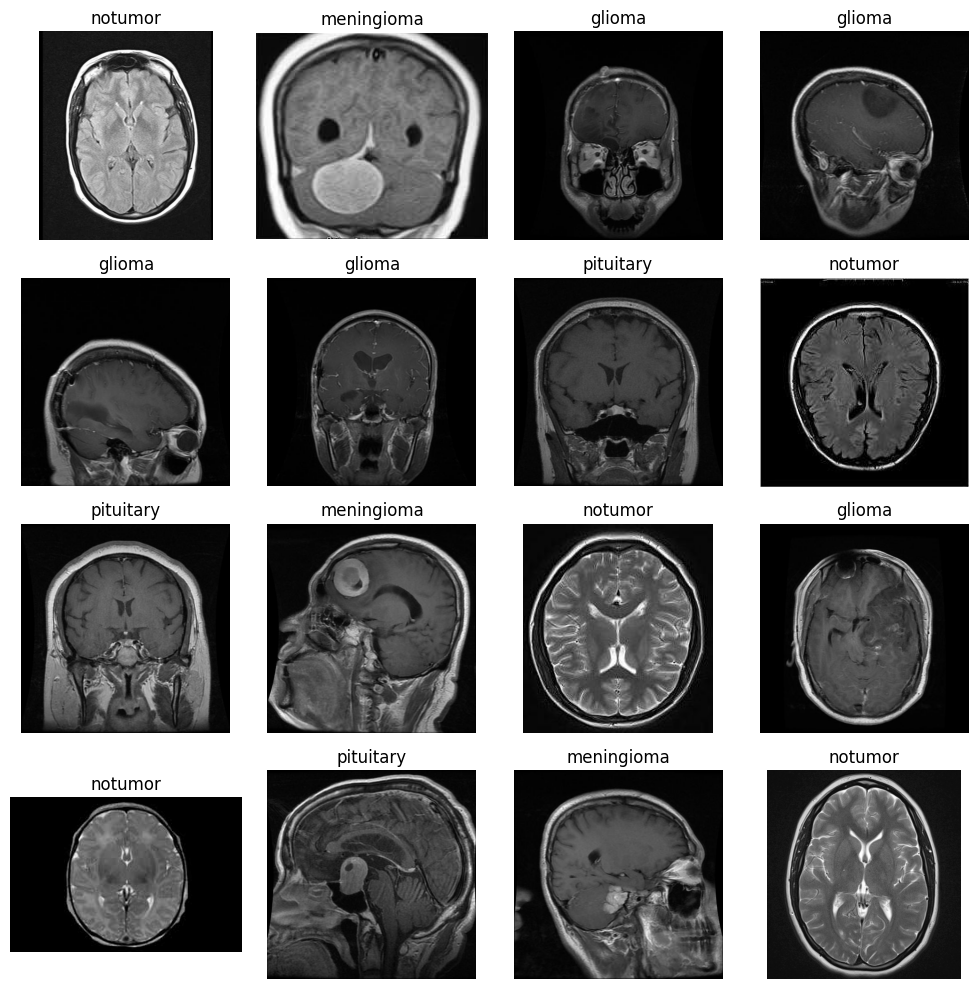

In [ ]:
import random

plt.figure(figsize=(10,10))

for i in range(16):
    idx = random.randint(0, len(all_images)-1)

    img = cv2.imread(all_images[idx])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(4,4,i+1)
    plt.imshow(img)
    plt.title(classes[all_labels[idx]])
    plt.axis("off")

plt.tight_layout()
plt.savefig("dataset_grid.png", dpi=300)
plt.show()

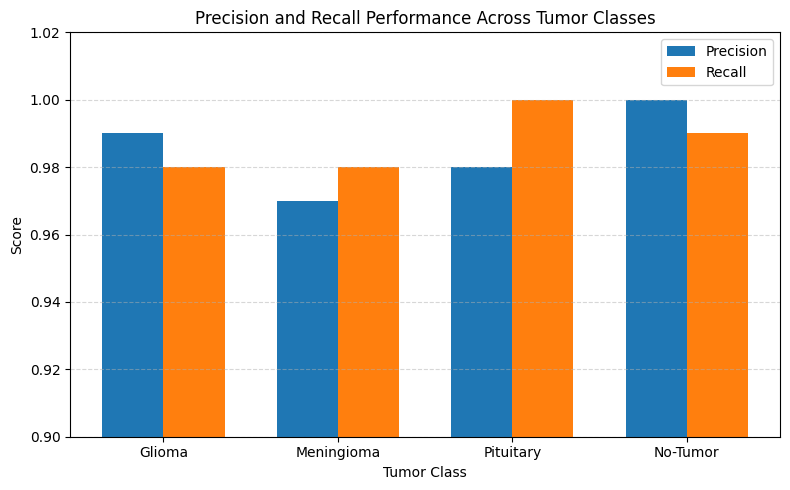

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['Glioma', 'Meningioma', 'Pituitary', 'No-Tumor']

precision = [0.99, 0.97, 0.98, 1.00]
recall = [0.98, 0.98, 1.00, 0.99]

x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, precision, width, label='Precision')
plt.bar(x + width/2, recall, width, label='Recall')

plt.xticks(x, classes)
plt.ylabel('Score')
plt.ylim(0.9, 1.02)
plt.xlabel('Tumor Class')
plt.title('Precision and Recall Performance Across Tumor Classes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()